## PyTorch Custom Datasets

### Importing necessary libraries and setup device agnostic code

In [1]:
import torch
from torch import nn

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.7.1+cu118


In [2]:
# setup devcie agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Get some data

the custom dataset is a subset of Food101 dataset. no. of images - 10% of Food101 dataset

In [3]:
import requests
import zipfile
from pathlib import Path

# setup a path for the data folder
data_path = Path("data")
image_path = data_path / "pizza_steak_sushi"

# if the folder doesn't exist, download and prepare it
if image_path.is_dir():
        print(f"{image_path} already exists, skipping download...")
        
else:
    print(f"{image_path} does not exist. Downloading the folder...")
    image_path.mkdir(parents=True, exist_ok=True)
    
# Download the data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print(f"Downloading the dataset...")
    f.write(request.content)

# Unzip the data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping the data")
    zip_ref.extractall(image_path)

data\pizza_steak_sushi already exists, skipping download...
Unzipping the data


### Preparing the exploring the data

In [4]:
import os
def walk_through_dir(dir_path):
    """ Walks through dir_path returning its contents"""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in data\pizza_steak_sushi
There are 3 directories and 0 images in data\pizza_steak_sushi\test
There are 0 directories and 25 images in data\pizza_steak_sushi\test\pizza
There are 0 directories and 19 images in data\pizza_steak_sushi\test\steak
There are 0 directories and 31 images in data\pizza_steak_sushi\test\sushi
There are 3 directories and 0 images in data\pizza_steak_sushi\train
There are 0 directories and 78 images in data\pizza_steak_sushi\train\pizza
There are 0 directories and 75 images in data\pizza_steak_sushi\train\steak
There are 0 directories and 72 images in data\pizza_steak_sushi\train\sushi


In [6]:
# setup train and test paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### Visualizing the images

Random image path: data\pizza_steak_sushi\train\pizza\2760984.jpg
Image class: pizza
Image Height: 512
Image width: 512


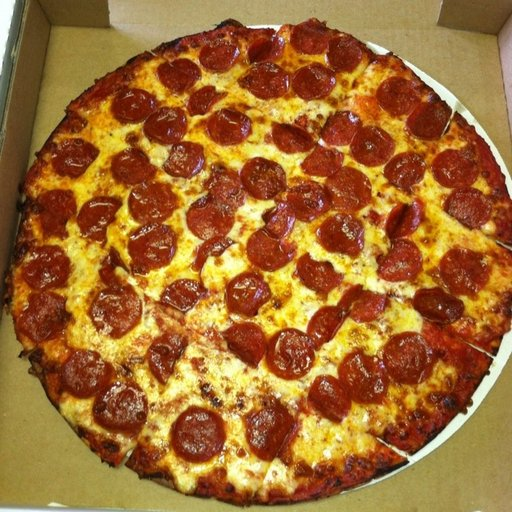

In [7]:
import random
from PIL import Image

# set seed
# random.seed(42)

# 1. get all the image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. pick a random image path
random_image_path = random.choice(image_path_list)
# print(random_image_path)

# 3. get the image class from the path name
image_class = random_image_path.parent.stem
# print(image_class)

# 4. open image
img = Image.open(random_image_path)

# 5. print metadaa
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image Height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

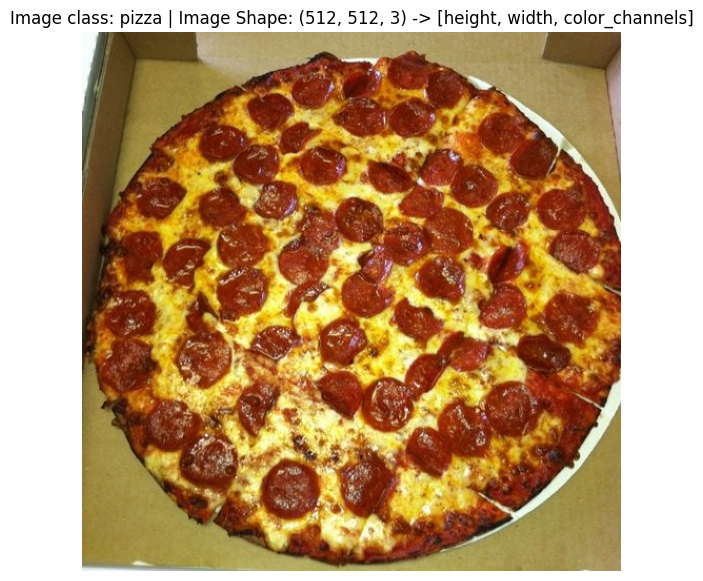

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# turn the image into an array
img_as_array = np.asarray(img)

# plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image Shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)

In [9]:
img_as_array

array([[[245, 254, 253],
        [245, 254, 253],
        [245, 254, 253],
        ...,
        [110,  83,  53],
        [112,  85,  55],
        [113,  86,  56]],

       [[245, 254, 253],
        [245, 254, 253],
        [245, 254, 253],
        ...,
        [108,  81,  51],
        [110,  83,  53],
        [111,  84,  54]],

       [[245, 254, 253],
        [245, 254, 253],
        [245, 254, 253],
        ...,
        [105,  78,  48],
        [106,  79,  49],
        [107,  80,  50]],

       ...,

       [[217, 228, 220],
        [216, 227, 219],
        [215, 226, 220],
        ...,
        [167, 143,  95],
        [167, 144,  94],
        [168, 145,  95]],

       [[227, 242, 239],
        [227, 242, 239],
        [226, 240, 240],
        ...,
        [169, 145,  97],
        [168, 145,  95],
        [169, 146,  96]],

       [[224, 240, 239],
        [224, 240, 239],
        [224, 240, 240],
        ...,
        [170, 146,  98],
        [169, 146,  96],
        [168, 145,  95]]

### Transforming the data

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### Transforming the data with torchvision.trnasforms

In [11]:
# write a transform for image
data_transform = transforms.Compose([
    # resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # flip the images
    transforms.RandomHorizontalFlip(p=0.5),
    # turn the image into a torch tensor
    transforms.ToTensor()
])

In [12]:
data_transform(img)

tensor([[[0.4078, 0.4196, 0.4157,  ..., 0.3569, 0.8157, 0.9647],
         [0.3647, 0.3961, 0.4078,  ..., 0.3373, 0.7373, 0.9608],
         [0.3843, 0.3686, 0.3922,  ..., 0.3412, 0.6235, 0.9529],
         ...,
         [0.6353, 0.6471, 0.6471,  ..., 0.6078, 0.6078, 0.6039],
         [0.6549, 0.6549, 0.6588,  ..., 0.6039, 0.6000, 0.5961],
         [0.6627, 0.6627, 0.6745,  ..., 0.6627, 0.6667, 0.6745]],

        [[0.2980, 0.3020, 0.3098,  ..., 0.3686, 0.8471, 1.0000],
         [0.2588, 0.2824, 0.2980,  ..., 0.3412, 0.7725, 0.9961],
         [0.2784, 0.2588, 0.2824,  ..., 0.3373, 0.6588, 0.9922],
         ...,
         [0.5451, 0.5529, 0.5647,  ..., 0.5333, 0.5255, 0.5137],
         [0.5647, 0.5647, 0.5765,  ..., 0.5412, 0.5333, 0.5255],
         [0.5686, 0.5725, 0.5961,  ..., 0.6627, 0.6745, 0.6824]],

        [[0.1765, 0.1686, 0.1569,  ..., 0.2941, 0.8235, 0.9922],
         [0.1451, 0.1529, 0.1490,  ..., 0.2549, 0.7451, 0.9922],
         [0.1725, 0.1333, 0.1373,  ..., 0.2392, 0.6235, 0.

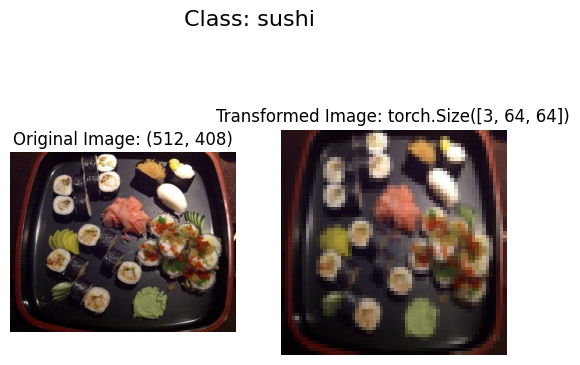

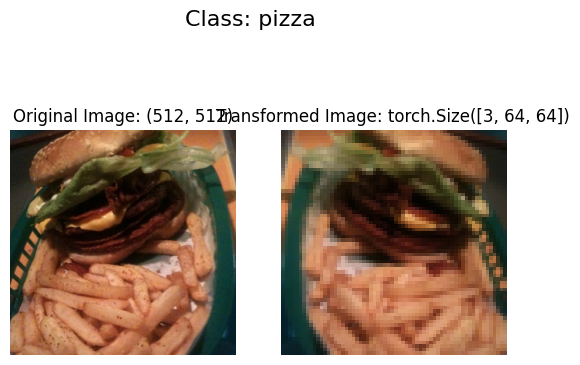

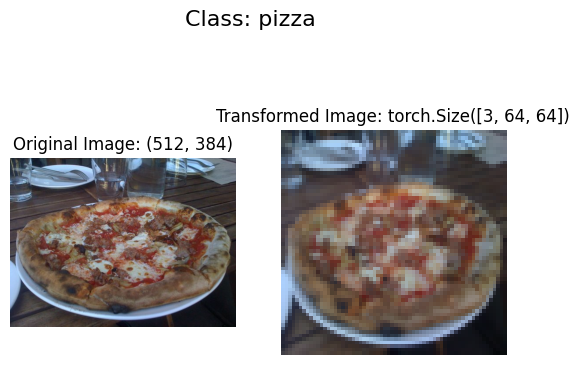

In [14]:
def plot_transformed_images(image_paths:list, transform, n=3, seed=None):
    random.seed(42)
    
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original Image: {f.size}")
            ax[0].axis(False)
            
            # Transform and plot target image
            transformed_image = transform(f) # Note: we will need to change the shape for matplotlib
            ax[1].imshow(transformed_image.permute(1, 2, 0))
            ax[1].set_title(f"Transformed Image: {transformed_image.shape}")
            ax[1].axis(False)
            
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42)
